In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib_venn import venn2

fsize = 20
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'

In [7]:
def load_evidence(fn):
    df = pd.read_json(fn)
    # Unwrap the 'source' column (contains a dictionary) into separate columns
    source_df = df['source'].apply(pd.Series)
    extracted_df = df['extracted'].apply(pd.Series).add_prefix('extracted_')
    derived_df = df['derived'].apply(pd.Series).add_prefix('derived_')
    # Combine the original DataFrame with the unwrapped columns
    df = pd.concat([df.drop(columns=['source', 'extracted', 'derived']), source_df, extracted_df, derived_df], axis=1)
    return df

In [8]:
human_fn = "../../data/adipose_Emont2022/evidence_human/evidence.json"
llm_fn = "../../data/adipose_Emont2022/evidence_llm/evidence.json"

df_human = load_evidence(human_fn)
df_llm = load_evidence(llm_fn)

In [12]:
df_llm

,source_type,source_rationale,source_id,extracted_organism,extracted_cell_type_label,extracted_cell_source,extracted_cell_state,extracted_feature_name,extracted_feature_type,derived_organism,derived_cell_type_id,derived_cell_type_label,derived_cell_source,derived_cell_state,derived_feature_name,derived_feature_type,derived_feature_identifier,derived_feature_identifier_type
0,text,We identified six distinct subpopulations of h...,text,homo_sapiens,ASPCells,None,None,PDGFRA,gene,homo_sapiens,None,ASPCells,None,None,PDGFRA,gene,None,None
1,text,"For example, mASPC2 and hASPC2 are characteriz...",text,homo_sapiens,Early Multipotent Progenitor Cells,None,None,Aldh1a3,gene,homo_sapiens,None,Early Multipotent Progenitor Cells,None,None,Aldh1a3,gene,None,None
2,text,"For example, mASPC2 and hASPC2 are characteriz...",text,homo_sapiens,Early Multipotent Progenitor Cells,None,None,ALDH1A3,gene,homo_sapiens,None,Early Multipotent Progenitor Cells,None,None,ALDH1A3,gene,None,None
3,text,"Similarly, mASPC4 and hASPC4 express Epha3 and...",text,homo_sapiens,Aregs,None,None,mASPC4,gene,homo_sapiens,None,Aregs,None,None,mASPC4,gene,None,None
4,text,"Similarly, mASPC4 and hASPC4 express Epha3 and...",text,homo_sapiens,Aregs,None,None,hASPC4,gene,homo_sapiens,None,Aregs,None,None,hASPC4,gene,None,None
5,text,"Thus, the adipokines adiponectin and adipsin (...",text,homo_sapiens,hAd3,None,None,CFD,gene,homo_sapiens,ADIPOCYTE,hAd3,None,None,CFD,gene,None,None
6,text,genes encoding insulin signalling components s...,text,homo_sapiens,hAd5,None,None,INSR,gene,homo_sapiens,ADIPOCYTE,hAd5,None,None,INSR,gene,None,None
7,text,genes encoding insulin signalling components s...,text,homo_sapiens,hAd5,None,None,IRS1,gene,homo_sapiens,ADIPOCYTE,hAd5,None,None,IRS1,gene,None,None
8,text,genes encoding insulin signalling components s...,text,homo_sapiens,hAd5,None,None,IRS2,gene,homo_sapiens,ADIPOCYTE,hAd5,None,None,IRS2,gene,None,None
9,text,hAd3 was associated with ‘triglyceride biosynt...,text,homo_sapiens,hAd3,None,None,DGAT2,gene,homo_sapiens,ADIPOCYTE,hAd3,None,None,DGAT2,gene,None,None


## For a Single Source Rationale...

In [28]:
SR = df_llm['source_rationale'][0]
ctl = 'derived_cell_type_label'
ft_id = 'derived_feature_name'

In [29]:
def get_ct_mg_pairs(df):
    df_ct_mg = df.loc[df['source_rationale'] == SR, [ctl,ft_id] ] # later change this to derived_cell_type_id
    return df_ct_mg

In [30]:
human_pairs = get_ct_mg_pairs(df_human)
llm_pairs = get_ct_mg_pairs(df_llm)

## Set Operations

In [31]:
def set_itx(a, b):
    return np.intersect1d(a, b).shape[0]
def set_itx_vals(a,b):
    return np.intersect1d(a,b)
def set_diff(a, b):
    return a.shape[0] - set_itx(a, b)
def create_venn(left, right, itx, set_a_name = "Set A", set_b_name = "Set B"):
    venn2(subsets = (left, right, itx), set_labels = (set_a_name, set_b_name))
    plt.show()

## Global Gene Comparison

#### Here, we are comparing if the LLM and the Human detected the same genes for a given source rationale.

In [32]:
human = human_pairs[ft_id]
llm = llm_pairs[ft_id]
left  = set_diff(human, llm)
itx   = set_itx(human, llm)
right = set_diff(llm, human)
itx_vals = set_itx_vals(human, llm) 

0 1 0 ['PDGFRA']


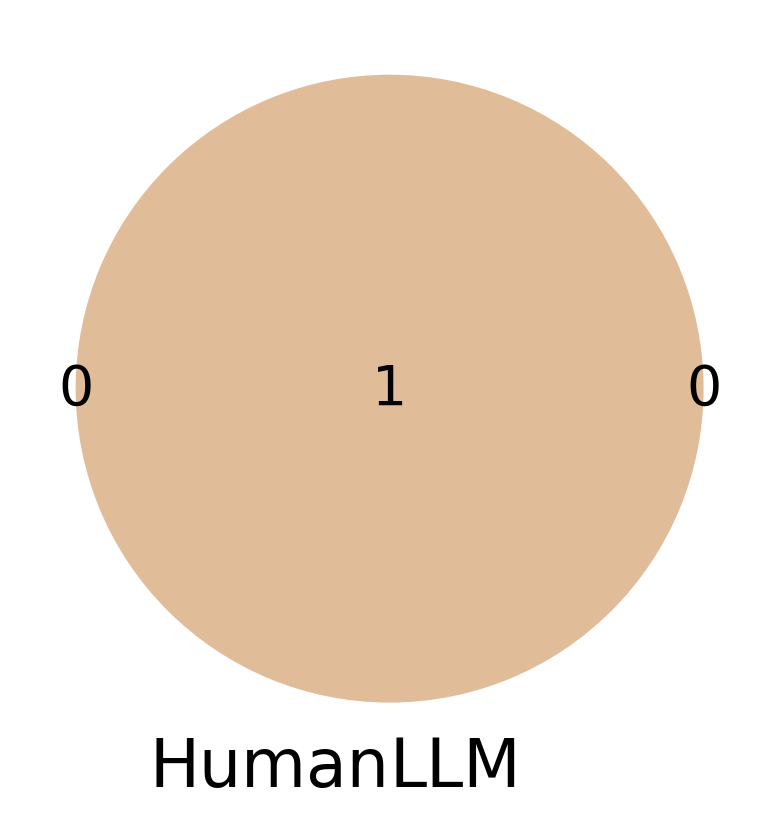

In [35]:
print(left, itx, right, itx_vals)
create_venn(left, right, itx, "Human", "LLM")

## Global Cell Type Comparison

#### Here, we are detecting if the LLM and the Human detected the same cell type labels for a given source rationale. This can either be based on pure extraction (setting ctl to 'derived_cell_type_label') or on conceptual understanding of the source rationale (setting ctl to 'derived_cell_type_id').

In [36]:
human = human_pairs[ctl]
llm = llm_pairs[ctl]
left  = set_diff(human, llm)
itx   = set_itx(human, llm)
right = set_diff(llm, human)
itx_vals = set_itx_vals(human, llm) 

1 0 1 []


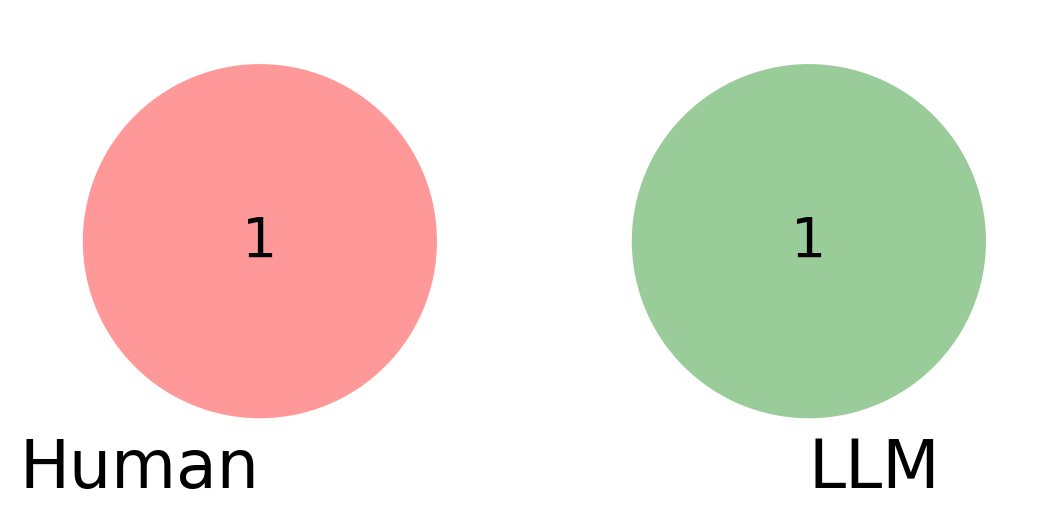

In [37]:
print(left, itx, right, itx_vals)
create_venn(left, right, itx, "Human", "LLM")